# Model Training -- Supervised Learning

In [65]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              roc_auc_score, classification_report)

In [66]:
df = pd.read_csv('../../data/processed/final_dataset_clean.csv')

df.tail()

,cluster_id,household_id,child_age_months,child_sex,breastfeeding,haz_score,waz_score,whz_score,stunted,underweight,...,district,wealth_index,disability,province,birth_weight_known,housing_quality,water_source,sanitation_type,education_level,household_education
61045,1027.0,17.0,46.0,0,2.0,-2.38,-2.52,-1.66,1,1,...,22.0,1.0,2.0,2,0,2.0,23.0,1.0,0.0,0.0
61046,1027.0,17.0,53.0,0,2.0,-0.66,-1.71,-1.71,0,0,...,22.0,1.0,2.0,2,1,2.0,23.0,1.0,0.0,0.0
61047,1027.0,17.0,23.0,0,1.0,-3.55,-3.51,-2.54,1,1,...,22.0,1.0,0.0,2,1,2.0,23.0,1.0,0.0,0.0
61048,1027.0,19.0,11.0,1,2.0,-2.45,-2.67,-1.20,1,1,...,22.0,1.0,0.0,2,0,2.0,11.0,1.0,0.0,0.0
61049,1027.0,20.0,44.0,1,2.0,-3.57,-2.98,-1.27,1,1,...,22.0,1.0,2.0,2,0,3.0,11.0,1.0,0.0,0.0


## Separate Features and Traget

The features will be the inputs of the models, the target will be the output.<br><br>
Some features were dropped initially, which were, when they were used, causing overfitting in the models.

In [ ]:
# X = features
# dropping target column, and columns not required for model training
features = [
        'child_age_months',
        'mother_education',
        'wealth_index',
        'urban_rural',
        'province'
]

X = df[features]

# y = target
y = df['stunted']

In [68]:
print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Features: ['child_age_months', 'mother_education', 'wealth_index', 'urban_rural', 'province']
X shape: (61050, 5)
y distribution:
stunted
0    33527
1    27523
Name: count, dtype: int64


## Separate Training and Testing

80% data is being sued to train the models while 20% is being used to test it to measure its accuracy. We are splitting the dataset in likewise fashion.

In [69]:
# separating training and testing data for both features and target. 
# 80% of the data is for training the model, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,}")
print(f"Testing set: {X_test.shape[0]:,}")

Training set: 48,840
Testing set: 12,210


## Evaluation Function

In [70]:
# function to print evaluation metrics
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall': round(recall_score(y_true, y_pred) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob) * 100, 2)
    }

## Training Random Forest

In [91]:
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print("\nTraining complete.")


Training Random Forest...

Training complete.


In [92]:
results = pd.DataFrame([
    evaluate('Random Forest', y_test, rf_pred, rf_prob),
])
print("Model Evaluation\n")
print(results.to_string(index=False))

Model Evaluation

        Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
Random Forest     59.25     57.54      54.27   61.24    62.58


## Training XGBoost

In [93]:
import xgboost as xgb
from xgboost import XGBClassifier

In [94]:
# creating model instance
bst = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.3, 
    scale_pos_weight=1.2,
    objective='binary:logistic',
)

In [95]:
print("\nTraining XGBoost...")
# fit model
bst.fit(X_train, y_train)

# make predictions
preds = bst.predict(X_test)
probs = bst.predict_proba(X_test)[:, 1]
print("\nTraining complete.")


Training XGBoost...

Training complete.


In [96]:
results = pd.DataFrame([
    evaluate('XGBoost', y_test, preds, probs),
])
print("Model Evaluation\n")
print(results.to_string(index=False))

Model Evaluation

  Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
XGBoost     60.96     58.97      56.04   62.23    65.46


## LightGBM

In [97]:
import lightgbm as lgb

In [100]:
print("\nTraining LightGBM...")
clf = lgb.LGBMClassifier(class_weight='balanced')
clf.fit(X_train, y_train)

# predict the results
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
print("\nTraining complete.")


Training LightGBM...
[LightGBM] [Info] Number of positive: 22018, number of negative: 26822
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 48840, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Training complete.


In [101]:
results = pd.DataFrame([
    evaluate('LightGBM', y_test, y_pred, y_prob),
])
print("Model Evaluation\n")
print(results.to_string(index=False))

Model Evaluation

   Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
LightGBM     61.12     59.91      55.98   64.43    66.36


## Comparing Models Through Plots

In [102]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [103]:
results_combined = pd.DataFrame([
    evaluate('Random Forest',     y_test, rf_pred, rf_prob),
    evaluate('XGBoost', y_test, preds, probs),
    evaluate('LightGBM',     y_test, y_pred, y_prob),
])


### Grouped Bar Chart

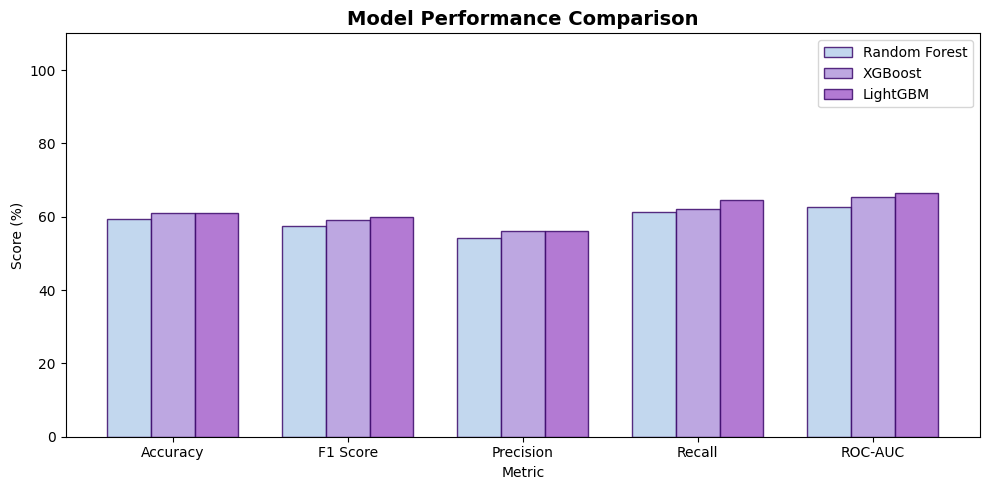

In [104]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC']

x = np.arange(len(metrics))
width = 0.25
colors = ['#b8d0eb', '#b298dc', '#a663cc']
edgecolor = '#3c096c'

for i, (_, row) in enumerate(results_combined.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i], edgecolor=edgecolor, alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("charts/model_comparison.png")
plt.show()

### Confusion Matrix

In [105]:
import seaborn as sns

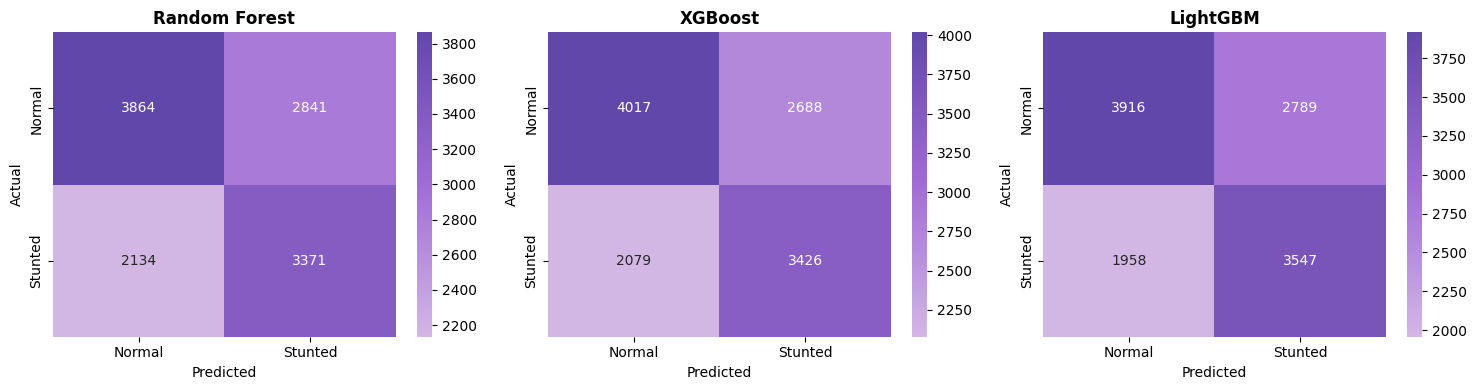

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

custom_cmap = LinearSegmentedColormap.from_list('custom', ['#d2b7e5', '#a06cd5', '#6247aa'])

models_info = [
    ('Random Forest', rf_pred),
    ('XGBoost', preds),
    ('LightGBM', y_pred)
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, ax=ax,
                xticklabels=['Normal', 'Stunted'],
                yticklabels=['Normal', 'Stunted'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
plt.tight_layout()
plt.savefig("charts/confusion_matrices.png")
plt.show()